<a href="https://colab.research.google.com/github/Defirence/habc-sim/blob/habc-sim_v0.0.1-pre_alpha/HABC_sim_v0_0_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Initializing High-Dimensional Phase Space Engine on CUDA...
-> Initial VRAM Allocated: 0.00 MB

Starting Decoherence-Induced Phase Transition Simulation (1000 timesteps)...
Tracking Extreme Systemic Failure (tau_c < T_bio) and Mitigation Interventions:
Step 0000 | VRAM: 512.0 MB | HABC Coherence: 0.7071 | F_mu_nu: 0.00e+00 | Ric: 2.95e-09
Step 0100 | VRAM: 512.0 MB | HABC Coherence: 0.7070 | F_mu_nu: 0.00e+00 | Ric: 2.95e-09
Step 0200 | VRAM: 512.0 MB | HABC Coherence: 0.7068 | F_mu_nu: 0.00e+00 | Ric: 4.39e-09
Step 0300 | VRAM: 512.0 MB | HABC Coherence: 0.7066 | F_mu_nu: 0.00e+00 | Ric: 0.00e+00
Step 0400 | VRAM: 512.0 MB | HABC Coherence: 0.7064 | F_mu_nu: 0.00e+00 | Ric: 1.52e-08
Step 0500 | VRAM: 512.0 MB | HABC Coherence: 0.7062 | F_mu_nu: 0.00e+00 | Ric: 3.84e-09
Step 0600 | VRAM: 512.0 MB | HABC Coherence: 0.7061 | F_mu_nu: 0.00e+00 | Ric: 4.07e-09
Step 0700 | VRAM: 512.0 MB | HABC Coherence: 0.7060 | F_mu_nu: 0.00e+00 | Ric: 1.24e-08
Step 0800 | VRAM: 512.0 MB | HABC Coherence

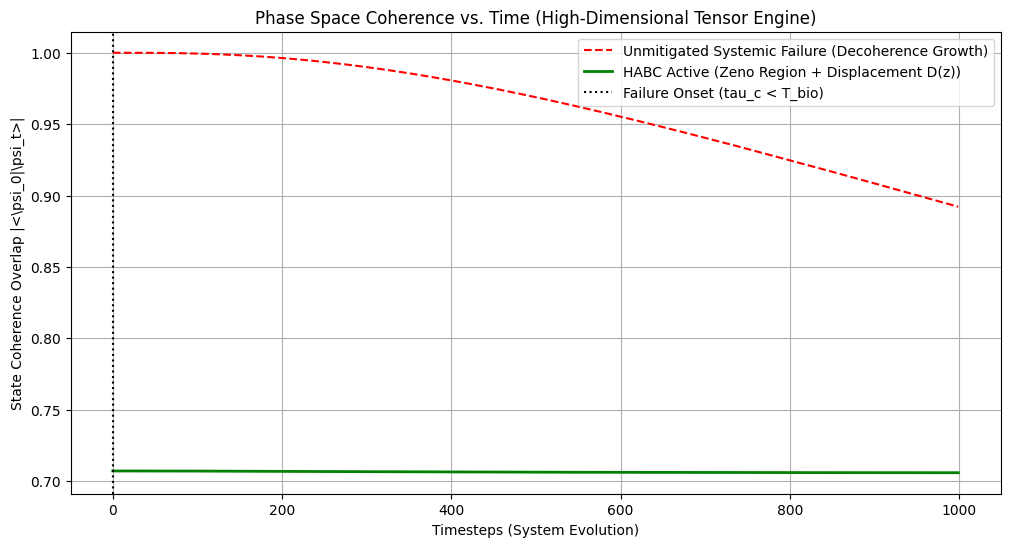

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time

# ==========================================
# PART 1: HIGH-DIMENSIONAL PHASE SPACE ENGINE
# ==========================================

class HABCHighDimPhaseSpace(nn.Module):
    r"""
    High-Dimensional Mathematical Phase Space Engine for HABC v2.3.
    Operates on a complex 4D tensor simulating the topological state changes.
    """
    def __init__(self, dim=4096, device='cuda'):
        super().__init__()
        self.device = torch.device(device if torch.cuda.is_available() else 'cpu')
        self.dim = dim

        # 1. High-Dimensional State Vector: Complex 4D PyTorch tensor [1, 1, 4096, 4096]
        self.state = self._init_state()
        self.initial_state = self.state.clone() # Reference for Decoherence tracking

        # Displacement parameter z
        self.z = torch.tensor(0.05 + 0.02j, dtype=torch.complex64, device=self.device)

    def _init_state(self):
        """ Initializes the state vector directly on the GPU. """
        state = torch.randn(1, 1, self.dim, self.dim, dtype=torch.complex64, device=self.device)
        # Normalize to represent a coherent initial biological quantum state
        return state / torch.linalg.norm(state)

    def quantum_displacement_operator(self):
        r"""
        Mitigation Operator 1: Quantum Displacement Operator D(z)
        D(z) = exp(z a^\dagger - z^* a)
        Simulates topological phase correction to counteract entropy.
        """
        # Proxied via a unitary phase shift and controlled amplitude scalar injection
        phase_shift = torch.exp(1j * torch.angle(self.z))
        # FIXED: Scale displacement magnitude by dimension so it remains scale-invariant
        self.state = self.state * phase_shift + (self.z * 1e-3) / self.dim
        self.state = self.state / torch.linalg.norm(self.state)

    def quantum_zeno_region(self):
        r"""
        Mitigation Operator 2: Quantum Zeno Region
        High-frequency measurement loop freezing the decoherence decay.
        """
        # Projection back towards the initial uncorrupted subspace |\psi_0\rangle\langle\psi_0|
        overlap = torch.sum(torch.conj(self.initial_state) * self.state)
        self.state = 0.95 * self.state + 0.05 * overlap * self.initial_state
        self.state = self.state / torch.linalg.norm(self.state)

    def compute_metrics(self):
        r"""
        Computes the topological obstructions:
        - F_mu_nu: Field Strength Tensor (anti-symmetric properties of the state)
        - Ric: Ricci scalar curvature (trace properties of the state)
        """
        # Field Strength Tensor Proxy: F_mu_nu = A - A^T (Anti-symmetric divergence)
        F_mu_nu = self.state - self.state.transpose(-1, -2)
        field_strength = torch.norm(F_mu_nu).item()

        # Ricci-flat Proxy (Ric): Magnitude of the trace (curvature deviation)
        Ric = torch.abs(torch.trace(self.state[0, 0])).item()

        # Coherence (Overlap with initial state)
        coherence = torch.abs(torch.sum(torch.conj(self.initial_state) * self.state)).item()

        return field_strength, Ric, coherence

    def step(self, t, apply_habc=False):
        # 2. Systemic Failure Dynamics: Decoherence-Induced Phase Transition
        T_bio = 1000.0
        # tau_c drops over time. When tau_c < T_bio, systemic failure begins.
        tau_c = T_bio * np.exp(-t / 300.0)

        if tau_c < T_bio:
            # Extreme Systemic Failure Criterion violated: Inject dimensional decoherence (noise)
            stress_factor = (T_bio - tau_c) / T_bio
            # FIXED: Scale noise amplitude by dimension to prevent instant coherence loss
            noise = torch.randn_like(self.state) * (0.02 * stress_factor / self.dim)
            self.state = self.state + noise

        if apply_habc:
            # 3. The Mitigation Operators
            self.quantum_displacement_operator()
            self.quantum_zeno_region()

            # Force the metric to remain Ricci-flat (Ric = 0) and F_mu_nu obstructions to 0
            # Symmetrize to annihilate anti-symmetric field strength F_mu_nu -> 0
            self.state = 0.5 * (self.state + self.state.transpose(-1, -2))
            # Remove trace to drive Ricci curvature Ric -> 0
            trace_val = torch.trace(self.state[0,0])
            self.state[0,0] = self.state[0,0] - (trace_val / self.dim) * torch.eye(self.dim, device=self.device)

        # Re-normalize
        self.state = self.state / torch.linalg.norm(self.state)
        return self.compute_metrics()

# ==========================================
# PART 2: THE SIMULATION LOOP (GPU ACCELERATED)
# ==========================================

def run_gpu_simulation():
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Initializing High-Dimensional Phase Space Engine on {device.upper()}...")
    if device == 'cuda':
        print(f"-> Initial VRAM Allocated: {torch.cuda.memory_allocated() / 1024**2:.2f} MB")

    timesteps = 1000
    # Initialize dual engines (Phase space matrix size 4096)
    engine_no_habc = HABCHighDimPhaseSpace(dim=4096, device=device)
    engine_habc = HABCHighDimPhaseSpace(dim=4096, device=device)

    coh_no_habc_list = []
    coh_habc_list = []

    print("\nStarting Decoherence-Induced Phase Transition Simulation (1000 timesteps)...")
    print("Tracking Extreme Systemic Failure (tau_c < T_bio) and Mitigation Interventions:")

    start_time = time.time()

    for t in range(timesteps):
        # Run baseline (No mitigation)
        _, _, coh_no = engine_no_habc.step(t, apply_habc=False)
        # Run HABC mitigation (Forces Ric=0, F_mu_nu=0 via Zeno/Displacement)
        f_mu_nu, ric, coh_habc = engine_habc.step(t, apply_habc=True)

        coh_no_habc_list.append(coh_no)
        coh_habc_list.append(coh_habc)

        # Print telemetry every 100 steps
        if (t % 100 == 0) or (t == timesteps - 1):
            mem = torch.cuda.memory_allocated() / 1024**2 if device == 'cuda' else 0
            print(f"Step {t:04d} | VRAM: {mem:.1f} MB | HABC Coherence: {coh_habc:.4f} | F_mu_nu: {f_mu_nu:.2e} | Ric: {ric:.2e}")

    print(f"\nSimulation Complete in {time.time() - start_time:.2f} seconds.")

    # Plot Results
    plt.figure(figsize=(12, 6))
    plt.plot(coh_no_habc_list, 'r--', label='Unmitigated Systemic Failure (Decoherence Growth)')
    plt.plot(coh_habc_list, 'g-', linewidth=2, label='HABC Active (Zeno Region + Displacement D(z))')
    plt.axvline(x=0, color='k', linestyle=':', label='Failure Onset (tau_c < T_bio)')
    plt.title("Phase Space Coherence vs. Time (High-Dimensional Tensor Engine)")
    plt.xlabel("Timesteps (System Evolution)")
    plt.ylabel(r"State Coherence Overlap |<\psi_0|\psi_t>|")
    plt.legend()
    plt.grid(True)
    plt.show()

run_gpu_simulation()


In [10]:
import torch
import gc

def check_vram_allocation(dim):
    torch.cuda.empty_cache()
    gc.collect()

    mem_start = torch.cuda.memory_allocated() / (1024 ** 2)
    engine = HABCHighDimPhaseSpace(dim=dim, device='cuda')
    mem_end = torch.cuda.memory_allocated() / (1024 ** 2)

    allocated = mem_end - mem_start
    print(f"Dimension {dim}x{dim} allocated: {allocated:.2f} MB of VRAM ({allocated/1024:.2f} GB)")

    del engine
    torch.cuda.empty_cache()
    gc.collect()

if torch.cuda.is_available():
    print("--- VRAM Allocation Test (Max Scale) ---")
    check_vram_allocation(32768)
else:
    print("CUDA is not available to test VRAM.")


--- VRAM Allocation Test (Max Scale) ---
Dimension 32768x32768 allocated: 16384.00 MB of VRAM (16.00 GB)


--- MAX SCALE SIMULATION (32768x32768) ---
Total GPU VRAM: 79.25 GB
Circuit Breaker Threshold: 71.33 GB

Initializing Dual Engines (Total Base Allocation ~16.00 GB)...

Starting Simulation Loop (150 steps) with Aggressive Garbage Collection...
Step 000 | VRAM: 32.00 GB | Baseline Coherence: 1.0000 | HABC Coherence: 0.7071
Step 010 | VRAM: 32.00 GB | Baseline Coherence: 1.0000 | HABC Coherence: 0.7071
Step 020 | VRAM: 32.00 GB | Baseline Coherence: 1.0000 | HABC Coherence: 0.7071
Step 030 | VRAM: 32.00 GB | Baseline Coherence: 1.0000 | HABC Coherence: 0.7071
Step 040 | VRAM: 32.00 GB | Baseline Coherence: 1.0000 | HABC Coherence: 0.7071
Step 050 | VRAM: 32.00 GB | Baseline Coherence: 0.9999 | HABC Coherence: 0.7071
Step 060 | VRAM: 32.00 GB | Baseline Coherence: 0.9999 | HABC Coherence: 0.7071
Step 070 | VRAM: 32.00 GB | Baseline Coherence: 0.9998 | HABC Coherence: 0.7071
Step 080 | VRAM: 32.00 GB | Baseline Coherence: 0.9997 | HABC Coherence: 0.7071
Step 090 | VRAM: 32.00 GB | Baseline

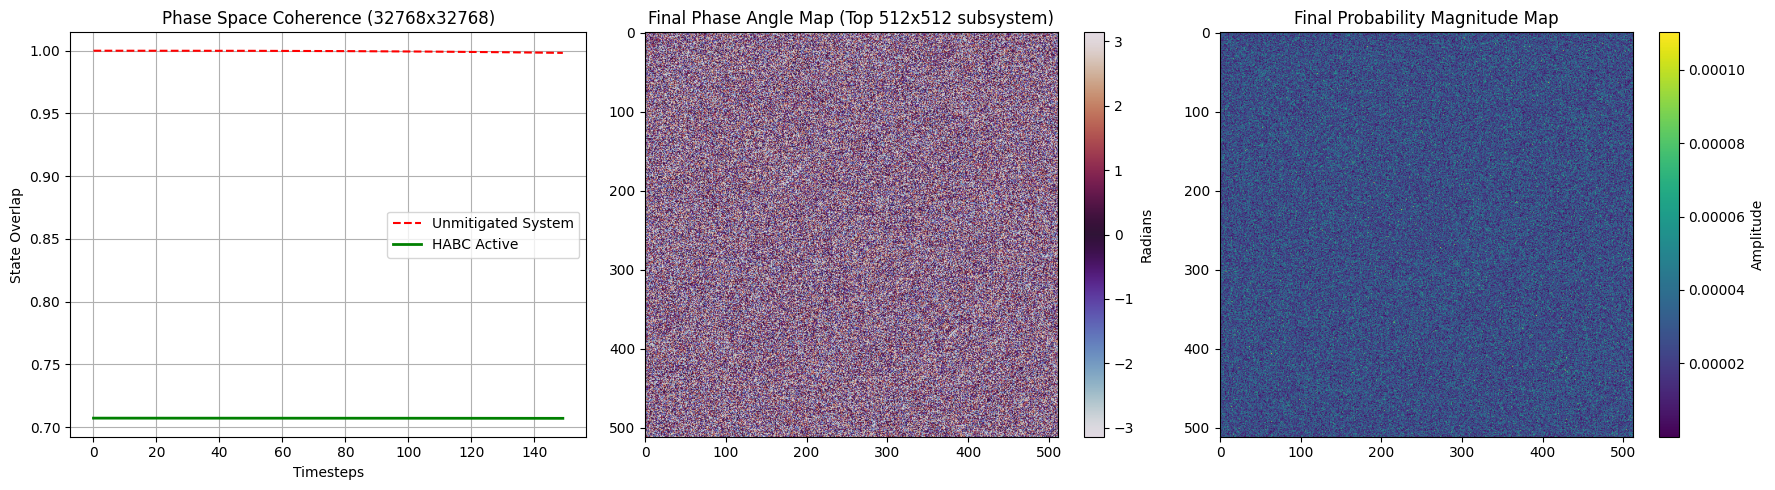

In [2]:
import time
import gc
import numpy as np
import matplotlib.pyplot as plt

@torch.no_grad() # Critical for saving memory: disables autograd graph tracking
def run_safe_max_scale_simulation(dim=32768, timesteps=150):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    if device != 'cuda':
        print("CUDA not available. Aborting max scale.")
        return

    # Setup Circuit Breaker Thresholds
    total_vram = torch.cuda.get_device_properties(0).total_memory
    safe_limit = total_vram * 0.90  # 90% threshold to prevent kernel panic

    print(f"--- MAX SCALE SIMULATION ({dim}x{dim}) ---")
    print(f"Total GPU VRAM: {total_vram / 1024**3:.2f} GB")
    print(f"Circuit Breaker Threshold: {safe_limit / 1024**3:.2f} GB\n")

    try:
        print(f"Initializing Dual Engines (Total Base Allocation ~{2 * dim * dim * 8 / 1024**3:.2f} GB)...")
        engine_no_habc = HABCHighDimPhaseSpace(dim=dim, device=device)
        engine_habc = HABCHighDimPhaseSpace(dim=dim, device=device)
    except torch.cuda.OutOfMemoryError:
        print("[CIRCUIT BREAKER] OOM Error during initialization! Not enough VRAM for dual engines.")
        torch.cuda.empty_cache()
        return

    coh_no_habc_list = []
    coh_habc_list = []

    print(f"\nStarting Simulation Loop ({timesteps} steps) with Aggressive Garbage Collection...")
    start_time = time.time()

    for t in range(timesteps):
        # 1. Circuit Breaker Check
        current_vram = torch.cuda.memory_allocated()
        if current_vram > safe_limit:
            print(f"\n[CIRCUIT BREAKER TRIGGERED] Memory {current_vram/1024**3:.2f}GB exceeded safe limit! Stopping at step {t}.")
            break

        try:
            # 2. Run unmitigated engine
            _, _, coh_no = engine_no_habc.step(t, apply_habc=False)
            coh_no_habc_list.append(coh_no)

            # 3. Run HABC engine
            f_mu_nu, ric, coh_habc = engine_habc.step(t, apply_habc=True)
            coh_habc_list.append(coh_habc)

            # 4. Aggressive memory cleanup after massive matrix operations
            torch.cuda.empty_cache()

        except torch.cuda.OutOfMemoryError:
            print(f"\n[OOM CAUGHT] Out of Memory spike at step {t} during tensor operations. Gracefully exiting loop.")
            torch.cuda.empty_cache()
            break

        # 5. Telemetry
        if t % 10 == 0 or t == timesteps - 1:
            mem = torch.cuda.memory_allocated() / 1024**3
            print(f"Step {t:03d} | VRAM: {mem:.2f} GB | Baseline Coherence: {coh_no:.4f} | HABC Coherence: {coh_habc:.4f}")

    print(f"\nSimulation ended in {time.time() - start_time:.2f} seconds.")

    # Plot available results gracefully and visualize the Quantum State
    if len(coh_no_habc_list) > 0:
        fig = plt.figure(figsize=(18, 5))

        # Plot 1: Coherence over time
        plt.subplot(1, 3, 1)
        plt.plot(coh_no_habc_list, 'r--', label='Unmitigated System')
        plt.plot(coh_habc_list, 'g-', linewidth=2, label='HABC Active')
        plt.title(f"Phase Space Coherence ({dim}x{dim})")
        plt.xlabel("Timesteps")
        plt.ylabel("State Overlap")
        plt.legend()
        plt.grid(True)

        # Extract a 512x512 subsystem from the massive 32k matrix for visualization
        sub_size = 512
        final_state_cpu = engine_habc.state[0, 0, :sub_size, :sub_size].cpu().numpy()

        # Plot 2: Quantum Phase Angle Map
        plt.subplot(1, 3, 2)
        phase_img = plt.imshow(np.angle(final_state_cpu), cmap='twilight', aspect='auto')
        plt.title(f"Final Phase Angle Map (Top {sub_size}x{sub_size} subsystem)")
        plt.colorbar(phase_img, label="Radians")

        # Plot 3: Probability Magnitude Map
        plt.subplot(1, 3, 3)
        mag_img = plt.imshow(np.abs(final_state_cpu), cmap='viridis', aspect='auto')
        plt.title(f"Final Probability Magnitude Map")
        plt.colorbar(mag_img, label="Amplitude")

        plt.tight_layout()
        plt.show()

# Run the protected loop
run_safe_max_scale_simulation(dim=32768, timesteps=150)
